# PCA - Code

## What you will learn in this course 🧐🧐

While a lot of theory come into place when creating a PCA, coding it is rather simple. In this course, you will learn:

* How to implement PCA
* How to choose principal components
* How to create covariance matrix
* How to implement basic linear algebra

In [1]:
# Import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE

## Dataset 🔥🔥

Let's use <a href="https://scikit-learn.org/stable/datasets/index.html#iris-dataset" target="_blank">Iris</a> from <a href="https://scikit-learn.org/stable/index.html" target="_blank"> Scikit Learn</a> to illustrate PCA.

In [2]:
# Import Iris
from sklearn.datasets import load_iris

# Load iris as a DataFrame seperated where we only get target values
# It is common to use _ when we don't need the values return by the tuple
# Here we don't need the target variable since we will perform unsupervised learning
X, _ = load_iris(return_X_y=True, as_frame=True)

# Visualize first 5 rows
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


As stated in the theory part of the course, we need to follow a few steps to get our PCA. Here they are:

<img src="https://full-stack-assets.s3.eu-west-3.amazonaws.com/images/PCA_process.png" alt="PCA_process"/>

## Normalize dataset 📏📏

Let's normalize our dataset before going anywhere:

In [3]:
# Import Standard Scaler
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
# StandardScaler will substract mean and divide by standard deviation to each observation
sc = StandardScaler()

# Apply StandardScaler to X
X = sc.fit_transform(X)

# Visualize first five rows
# Standard scaler transform X as numpy array. Therefore you can't use .head()
X[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

## Apply PCA 🚀🚀

Now, if we want to be fast, we can already apply <a href="https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA" target="_blank">PCA</a> on our dataset using from <a href="https://scikit-learn.org/stable/index.html" target="_blank">Scikit Learn</a>.

In [4]:
# import PCA
from sklearn.decomposition import PCA

# Instanciate PCA
# We can even specify how many components we want within the class
pca = PCA(n_components=2)

# Fit pca to our model
PC = pca.fit_transform(X)

# Visualize first five rows
PC[:5]

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538]])

What is this `PC` dataset? It is our dataset of Principal Components. Let's actually find our eigen-vectors using `.components_` property.

In [5]:
# Here are our eigen vectors
pca.components_

array([[ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654],
       [ 0.37741762,  0.92329566,  0.02449161,  0.06694199]])

This is also our $U$ matrix of $Eigen-vectors$ that we can find using SVD. To verify, we can multiply this matrix by our initial dataset, we get our `PC` matrix back.

In [6]:
# Let's multiply (use dot product) X by pca.components_ transpose
X.dot(pca.components_.T)[:5]

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538]])

`pca.components_` gives us an idea of how `PC` is built. For example:

In [7]:
# Get first principal component
PC1 = PC[:, 0]

# Visualize PC1
PC1[:5]

array([-2.26470281, -2.08096115, -2.36422905, -2.29938422, -2.38984217])

In [8]:
# Here is the associated eigen vector
eig_vec_1 = pca.components_[0, :]
eig_vec_1

array([ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654])

What it means is that `PC1` is a linear combination of:

`0.52*Sepal Length + (-0.27)*sepal width + 0.58*petal length + 0.56*petal width`

This is how we can interpret what `PC1` actually means! 💪

## Visualization 📊📊


Let's now visualize our new dataset!

In [9]:
# Import pandas
import pandas as pd

# Convert PC into a DataFrame
PC = pd.DataFrame(data=PC, columns=["PC1", "PC2"])

# PC Head
PC.head()

,PC1,PC2
0,-2.264703,0.480027
1,-2.080961,-0.674134
2,-2.364229,-0.341908
3,-2.299384,-0.597395
4,-2.389842,0.646835


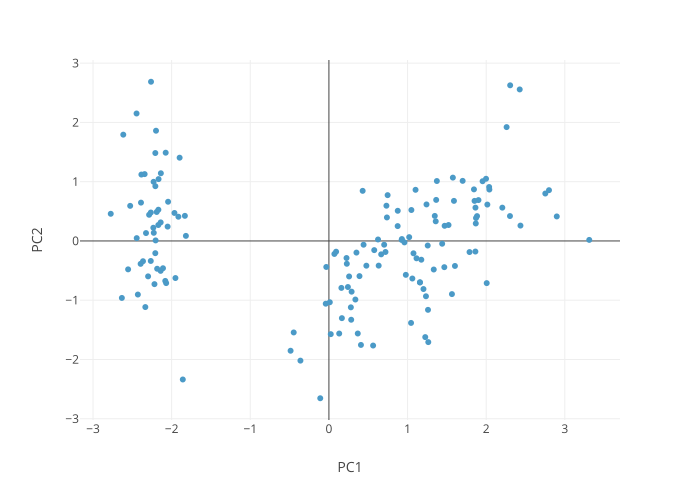

In [10]:
# Import plotly
import plotly.express as px

# Create scatterplot
fig = px.scatter(data_frame=PC, x="PC1", y="PC2")

# Show scatterplot
fig.show()

In [11]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762])

We can clearly visualize two clusters thanks to PCA! 🎉

## What is the link between PCA and SVD? 🤓🤓

At this point, you might be feeling that Scikit Learn is a little too much under the hood to understand fully how PCA works. If that's your case, you can read this section.

> It is completely optional, it is for you to have a better understanding of the concept but  you can definitely stick with `sklearn`.

Let's remind what SVD is:

$$A = U\Sigma V^\intercal$$

It basically says that we can decompose any matrix into 3 matrices containing $eigen-vectors$ and $eigen-values$ of the covariance matrix.

Let's take back our `X` matrix (which is already normalized).

In [12]:
# Here is our normalized iris dataset
X[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

We can use `numpy` to get $eigen-values$ and $eigen-vectors$. We need first to get the covariance matrix.

In [13]:
# Import numpy
import numpy as np

# Calculate covariance matrix by multiplying Xt by X
cov_mat = X.T.dot(X)

# Let's use Pandas to visualize our covariance matrix better
pd.DataFrame(cov_mat)

,0,1,2,3
0,150.000000,-17.635468,130.763066,122.691169
1,-17.635468,150.000000,-64.266016,-54.918890
2,130.763066,-64.266016,150.000000,144.429815
3,122.691169,-54.918890,144.429815,150.000000


🚨 Here we multiplied $X^\intercal$ by $X$. The reason why is because initally is $X$ is a matrix with vectors in columns whereas we need a matrix with vectors in rows to make SVD work. In any case it boils down to the same output. 🚨

Let's now get the $eigen - values$ and $eigen-vectors$ with `numpy`

In [14]:
# Use .linealg.eig to get eigen values and eigen vectors
eig_val, eig_vec = np.linalg.eig(cov_mat)

# Visualize both variables
eig_val, eig_vec

(array([437.77467248, 137.10457072,  22.01353134,   3.10722546]),
 array([[ 0.52106591, -0.37741762, -0.71956635,  0.26128628],
        [-0.26934744, -0.92329566,  0.24438178, -0.12350962],
        [ 0.5804131 , -0.02449161,  0.14212637, -0.80144925],
        [ 0.56485654, -0.06694199,  0.63427274,  0.52359713]]))

Let's now compare the `eig_vec` with `pca.components_`

In [15]:
# Let's transpose Eigen Vectors and print out the first two rows
print("Eigen Vectors")
print(eig_vec.T[:2, :])

# Add simple space
print()

# Print out pca components_
print("Principal components using sklearn")
print(pca.components_)

Eigen Vectors
[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [-0.37741762 -0.92329566 -0.02449161 -0.06694199]]

Principal components using sklearn
[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]


As you can see both are exactly the same!

> You might say that signs are not exactly equals, well actually signs are symetric so it comes down to the same thing in vector terms.

Let's now multiply `eig_vec` by `X` and see what we get!

In [16]:
X.dot(eig_vec)[:5]

array([[-2.26470281, -0.4800266 , -0.12770602,  0.0241682 ],
       [-2.08096115,  0.67413356, -0.23460885,  0.10300677],
       [-2.36422905,  0.34190802,  0.04420148,  0.02837705],
       [-2.29938422,  0.59739451,  0.09129011, -0.06595556],
       [-2.38984217, -0.64683538,  0.0157382 , -0.03592281]])

In [17]:
# Multiply X by eigen vectors
X_eig_vec = X.dot(eig_vec)
X_eig_vec[:5]

array([[-2.26470281, -0.4800266 , -0.12770602,  0.0241682 ],
       [-2.08096115,  0.67413356, -0.23460885,  0.10300677],
       [-2.36422905,  0.34190802,  0.04420148,  0.02837705],
       [-2.29938422,  0.59739451,  0.09129011, -0.06595556],
       [-2.38984217, -0.64683538,  0.0157382 , -0.03592281]])

In [18]:
# Visualize PC
PC[:5]

,PC1,PC2
0,-2.264703,0.480027
1,-2.080961,-0.674134
2,-2.364229,-0.341908
3,-2.299384,-0.597395
4,-2.389842,0.646835


As you can see they are both the same! Now why do we have only 2 `PCs`? Well let's simply get the covariance matrix of `X_eig_vec`

In [19]:
# We can use Numpy of multiply by its transpose
cov_mat_with_svd = np.cov(X_eig_vec.T) # <-- This is equal to X_eig_vec.T.dot(X_eig_vec)

# Transform into pandas for better visualization
cov_mat_with_svd = pd.DataFrame(cov_mat_with_svd)
cov_mat_with_svd

,0,1,2,3
0,2.938085e+00,-5.075638e-16,-1.534939e-16,8.766291e-16
1,-5.075638e-16,9.201649e-01,1.028260e-16,9.070625e-17
2,-1.534939e-16,1.028260e-16,1.477418e-01,2.989778e-17
3,8.766291e-16,9.070625e-17,2.989778e-17,2.085386e-02


As you can see all the values on the off-diagonals are very close to zero while the values of the diagonals are ordered and positive. Let's actually calculate the `explained_variance_ratio`

In [20]:
# Calculate explained variance for each pcs
# Initialize empty list
explained_variance = []
for i, _ in enumerate(cov_mat_with_svd.columns):
    exp_var = cov_mat_with_svd.iloc[i, i] / cov_mat_with_svd.sum().sum()
    explained_variance.append(exp_var)

explained_variance

[np.float64(0.7296244541329987),
 np.float64(0.2285076178670174),
 np.float64(0.036689218892828786),
 np.float64(0.005178709107154799)]

As you can see PC1 and PC2 are explaining respectively 73% and 23% of the variance. That is why we can keep them both and remove the others! 🙌

## Resources 📚📚

* <a href="https://www.mathsisfun.com/algebra/matrix-multiplying.html" target="_blank">How to multiply matrices</a>

* <a href="https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA" target="_blank">PCA</a>

* <a href="https://en.wikipedia.org/wiki/Dot_product" target="_blank">Dot Product</a>

* <a href="https://lpsa.swarthmore.edu/MtrxVibe/EigMat/MatrixEigen.html" target="_blank">How to find Eigen Values & Eigen Vectors</a>